# Fast Example: Lifetime based analysis

smfBursts provides several columns for analyzing the **mean** fluoresence lifetime of bursts, 
*if* the data was acquired with pulsed excitation.
This can be used in FRETLines to assess populations of bursts for conformational dyanmics.

See [Bart et. al. 2022](https://doi.org/10.1063/5.0089134) for detailed description of theory.

In the case of static FRET, the donor lifetime and FRET efficicy are proportional:

$\tau_{d,obs} = (1-E)\tau_{d,0}$

However, conformational dynamics result in deviations from this "static fret" line.
(Note however that non-conformational dynamics such as dye blinking also contribute, 
thus care should be take that these other effects are accounted for 
before interpreting your results as conformational dynamic).

First we load in the standard modules:

In [1]:
import numpy as np
import matplotlib.pyplot as plt

import smfbursts as smf

## Pre-processing: Burst Search and Correction Factors

First we load the data, in this example we will use a simple DNA hairpin used in 
[Harris et. al. 2022](https://doi.org/10.1038/s41467-022-28632-x),
the raw file is found in the [zenodo repository](https://zenodo.org/records/5902313)

In [2]:
raw = smf.hdf5.load('data/HP3_TE300_SPC630.hdf5')
data = smf.hdf5.regularize_dets(raw)

Then make burst searches to compute correction factors 
(see the [correction factors tutorial](FRETCorrectionsTutorial.ipynb) for more detailed tutorial of how to compute these).
Corrections are needed for accurate FRET, which is necessary for E-$\tau$ analysis.

In [3]:
# Background analysis
bg = smf.ff.make_bg(data, func=smf.bg.exp_mlefit, auto_threshold=True, tail_min=5e-4)
# burst search for correction factors
bs_acbs = smf.ff.make_burst_search(bg=bg['bg'], m=10, F=6.0, 
                                   streams=(smf.PhSel('0ex_1ex1em'),))
gate_acbs = smf.make_geq_gate(bs_acbs['NphActive_bg'], 50.0)
# burst search (dcbs) for E-tau analysis
bs_dcbs = smf.ff.make_burst_search(bg=bg['bg'], m=10, F=6.0,
                                   streams=(smf.PhSel('0ex'), 
                                            smf.PhSel('1ex1em')))

gate_dcbs = smf.make_geq_gate(bs_dcbs['NphDex_bg'], 50.0) 
gate_dcbs &= smf.make_geq_gate(bs_dcbs['NphAA_bg'], 30.0)

Plot and define thresholds for DO, AO and FRET populations

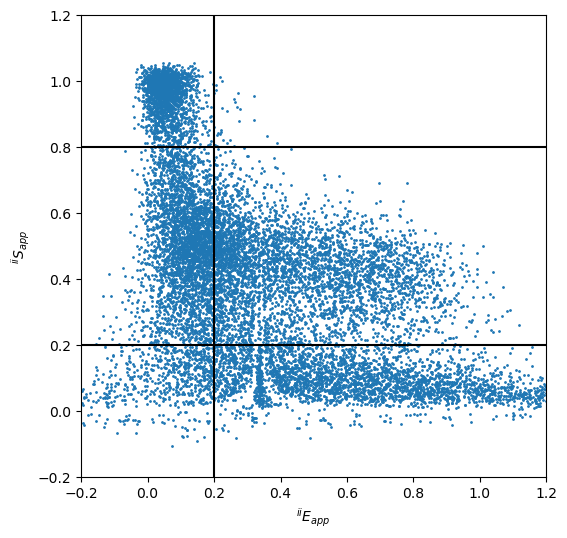

In [4]:
DO_thresh = 0.8
DO_ethresh = 0.2
AO_thresh = 0.2

fig, ax = plt.subplots(figsize=(6,6))
smf.plot.scatter(data, bs_acbs['E_bg'], bs_acbs['S_bg'], gate=gate_acbs, ax=ax, s=1.0)
ax.axhline(DO_thresh, c='k')
ax.axvline(DO_ethresh, c='k')
ax.axhline(AO_thresh, c='k')

ax.set_xlim([-0.2, 1.2])
ax.set_ylim([-0.2, 1.2]);

Build gates and compute $\alpha$ and $\delta$ cross-talk corrections

In [5]:
gate_do = gate_acbs & smf.make_geq_gate(bs_acbs['S_bg'], DO_thresh) 
gate_do &= smf.make_lt_gate(bs_acbs['E_bg'], DO_ethresh)
gate_ao = gate_acbs & smf.make_lt_gate(bs_acbs['S_bg'], AO_thresh)

alpha = smf.ff.crosstalk_correction(data, bs_acbs['E_bg'], gate=gate_do)
delta = smf.ff.crosstalk_correction(data, bs_acbs['S_bg'], gate=gate_ao)

bs_dcbs_ct = smf.ff.make_correction_factors(bs_dcbs['nphbg'], 
                                            alpha=alpha, delta=delta)

Check FRET populations.

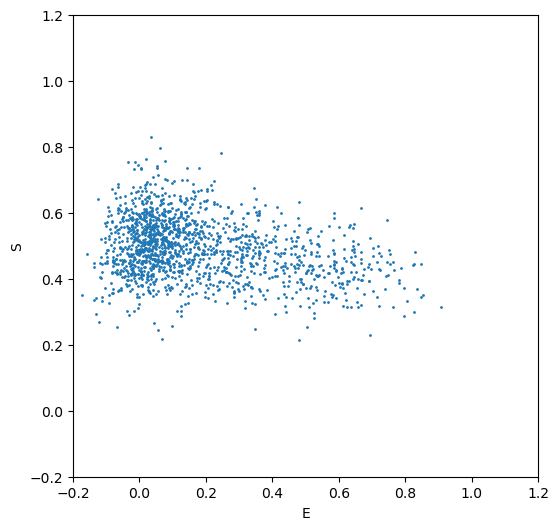

In [6]:
fig, ax = plt.subplots(figsize=(6,6))
smf.plot.scatter(data, bs_dcbs_ct['E'], bs_dcbs_ct['S'], gate=gate_dcbs, 
                 ax=ax, s=1.0)
# set standard axis limits for E-S plot
ax.set_xlim([-0.2, 1.2])
ax.set_ylim([-0.2, 1.2]);

In this case the dcbs looks good, we can use the global burst fit without further gating. In other cases, you may want to set $S$ thresholds to isolate the FRET population, or fit positions.

We can now compute the $\gamma$ and $\beta$ values.

In [7]:
# calculate gamma and beta,, inputs are data, E column, S column, 
# and gate of FRET bursts
gamma, beta = smf.ff.gamma_beta_bursts(data, bs_dcbs_ct['E'], 
                                       bs_dcbs_ct['S'], gate=gate_dcbs)
# create dictionary of columns around correction factors
dbs_dcbs_full = smf.ff.make_correction_factors(bs_dcbs['nphbg'], 
                                               alpha=alpha, delta=delta, 
                                               gamma=gamma, beta=beta)

## Defining IRF/IRF thresholds

To compute mean lifetimes, we need some information about the laser IRF.
So we will 

> **Attention**
> 
> Ideally you measure the IRF with scattered light or highly quenched sampe in a separate measuremnt.

But here, we will show how we can get an IRF by inverting a burst search.

The steps are:
1. Define a "permisive" burst search, with sliding window this means `F` close to 1
2. Use `smf.BurstOvlp` with `truthtable="inv"` to select ranges not in burst search (i.e. high confidence background)
3. Compute TCSPC decay of these time regions by summing the `nanohist`
4. Set regions of IRF that are background/not irf to 0 (easiest as fraction of maximum), this is not strictly necessary,
   but since most algorithms account for background, removing it from the IRF is generally valid.
   Also, for the `nanomean_bg` column in particular, the calculation is more reasonable when the IRF does not contain background
6. Set IRF in `smf.PhotonData.irf`

> **Note**
>
> Information on the IRF can actually be described in 2 ways, either with the detailed
> `smf.PhotonData.irf` meta-data dictionary, or in the `smf.PhotonData.irf_thresh`.

See the example code below:
for step 1, we define the `smf.Param` with type `smf.Bursts`, and appropriate `m`, `F` etc. values.
Then the background only region is defined with the `smf.param` with type `smf.BurstOvlp`,
in the "inverse" configuration.

In [8]:
###############################################################################
### NOTE:: It is better to measure the IRF experimentally instead of fitting
### or extracting from an inverted burst search
###############################################################################

# define permisive burst search
nonbgdd = smf.Param(smf.Bursts, m=10, F=1.01, stream=smf.PhSel('all'), bg=bg['bg'])
# make inverted burst search with BurstOvlp
irfrngdd = smf.Param(smf.BurstOvlp, truthtable='inv', bases=nonbgdd)
# define nanohist column
Irf_dd = smf.Column(irfrngdd, 'nanohist', smf.PhSel('0ex0em'))
irf_dd = data.get_column(Irf_dd).sum(axis=0) # sum hist of ranges to get decay

Below we plot the extracted IRF to make sure it is good, you can play with the value of `irf_frac`
to see what threshold to set for excluding background counts(the actual)

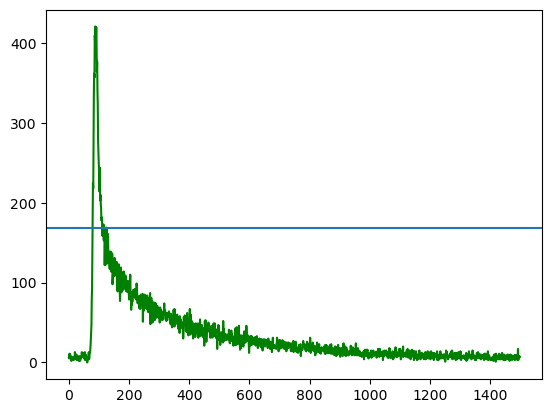

In [9]:
# choose fraction to set to zero
irf_frac = 0.4

# plot to 
plt.plot(irf_dd, c='g')
# plot line so we can check
plt.axhline(irf_dd.max()*irf_frac)

And finally, we use numpy boolean masks to set the regions less than the threshold to 0,
and in the `smf.PhotonData.irf` dictionary, with the appropriate key, specify the IRF.

Note that the last line can only be done once, this is considered static information in the data object.
If you need to change it, either reset the notebook, or create a new data object by reloading the file.

In [10]:
irf_dd[irf_dd < 0.4*irf_dd.max()] = 0
data.irf[smf.PhSel('0ex0em')] = irf_dd

## Lifetime plotting

And we can define the column for mean lifetime:

This is simple, we use the `nanomean_bg` column of the background adjusted counts `smf.Param` of type `smf.NphBG`,
which the fret factory functions create for us in the `"nphbg"` key of the dictionary.

The `nanomean_bg` uses an equation taking the photon nanotimes and background counts,
and the center of the IRF to compute an estimate of the mean fluoresence decay rate.
This computation is only marginally more complicated, and very similar to the mean of the nanotimes, thus the name.
By incorporating background, it is however a much better representation of the true fluoresence lifetime.

$\tau = \frac{ \left(\displaystyle\sum_{i=1}^{N}{t_{i}}\right) - n_{bg}\bar{t_{bg}}}{N-n_{bg}}$

where $N$ is the number of photons, each photon nanotime is $t_{i}$, (note that these are computed such that 0 is the center of the IRF)
$n_{bg}$ is the background counts, and $\bar{t_{bg}}$ is the expected mean of the background counts (the center of the excitation window). 

To define the nanomean column, use the `smf.NphBG` param, and a key of the desired `smf.PhSel` photon selection.

In [11]:
nanomean = smf.Column(bs_dcbs['nphbg'], 'nanomean_bg', smf.PhSel('0ex0em'))

A simple histogram plot will only show as much as a standard FRET histogram:

(array([  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   1,   1,   2,
          1,   1,   1,   1,   3,   1,   8,   6,   8,  10,  11,  18,  21,
         18,  24,  31,  44,  62,  64,  91,  91,  97, 104,  99,  98,  85,
         79,  88,  56,  59,  45,  35,  52,  19,  12,  20]),
 array([0.        , 0.10204082, 0.20408163, 0.30612245, 0.40816327,
        0.51020408, 0.6122449 , 0.71428571, 0.81632653, 0.91836735,
        1.02040816, 1.12244898, 1.2244898 , 1.32653061, 1.42857143,
        1.53061224, 1.63265306, 1.73469388, 1.83673469, 1.93877551,
        2.04081633, 2.14285714, 2.24489796, 2.34693878, 2.44897959,
        2.55102041, 2.65306122, 2.75510204, 2.85714286, 2.95918367,
        3.06122449, 3.16326531, 3.26530612, 3.36734694, 3.46938776,
        3.57142857, 3.67346939, 3.7755102 , 3.87755102, 3.97959184,
        4.08163265, 4.18367347, 4.28571429, 4.3877551 , 4.48979592,
        4.59183673, 4.69387755, 4.79591837, 4.89795918, 5.        ]),
 <BarContainer object of 49 artists>,
 

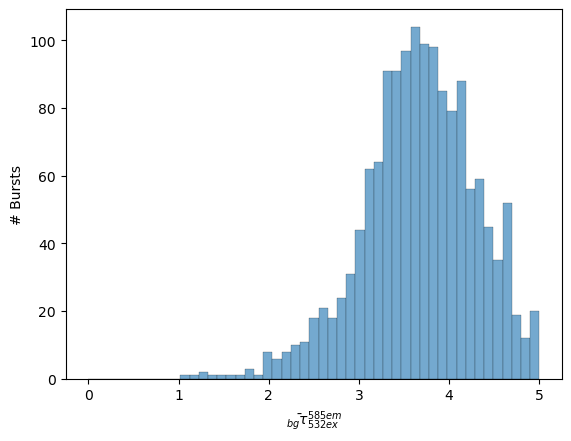

In [12]:
smf.plot.hist_bar(data, nanomean, gate=gate_dcbs, 
                  rescale=-9, bins=np.linspace(0, 5.0, 50), 
                  **smf.fretfactory.ALEXdefaults['histbar'])

But plotting E vs $\tau$ can show evidence of dynamics (if the expected 0 fret lifetime is known).

Details of how different E distributions are calculated will not be addressed here,
as each system will be different, choose your parameters for these accordingly.

Below we show the actual distribution of the bursts lifetime and E:

(<matplotlib.collections.PathCollection at 0x7aadeab85910>,
 Text(0.5, 0, '$\\bar{_{bg}\\tau}_{532ex}^{585em}\\: (ns)$'),
 Text(0, 0.5, 'E'))

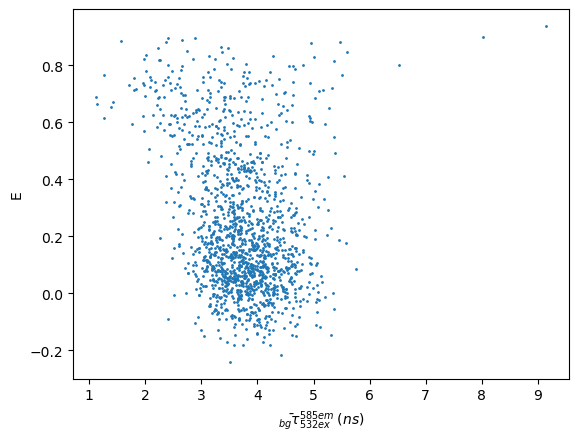

In [13]:
smf.plot.scatter(data, nanomean, dbs_dcbs_full['E'], 
                 gate=gate_dcbs, s=1.0, rescale=(-9, 0))

## Publication Recomendations

### Citations

Of course, after we are done we should remember to print out the citations wtih `smf.print_citations()` 
(or get them with `smf.get_citations()` instead for a more detailed list)

In [14]:
smf.print_citations()

1. Ingargiola, A., Lerner, E., Chung, S. Y., Weiss, S. & Michalet, X.
    FRETBursts: An open source toolkit for analysis of freely-diffusing Single-
    molecule FRET. PLoS ONE 11, 1–27 (2016).
2. Müller, B. K., Zaychikov, E., Bräuchle, C. & Lamb, D. C. Pulsed interleaved
    excitation. Biophysical Journal 89, 3508–3522 (2005).
3. Laurence, T. A., Kong, X., Jager, M. & Weiss, S. Probing structural
    heterogeneities and fluctuations of nucleic acids and denatured proteins.
    Proceedings of the National Academy of Sciences 102, 17348–17353 (2005).
4. Eggeling, C., Fries, J. R., Brand, L., Günther, R. & Seidel, C. A. M.
    Monitoring conformational dynamics of a single molecule by selective
    fluorescence spectroscopy. Proc. Natl. Acad. Sci. U.S.A. 95, 1556–1561
    (1998).
5. Fries, J. R., Brand, L., Eggeling, C., Köllner, M. & Seidel, C. A. M.
    Quantitative Identification of Different Single Molecules by Selective Time-
    Resolved Confocal Fluorescence Spectroscopy. J. Phy

### Print Params

It is also recomended to get descriptions of the parameters used for the analysis.

All `Param`, `Column`, and `GateGroup` objects have a `.description` property.
Printing this will generate a yaml-like string that is good to add to your supplementary data, as it exactly describes the object.

Since we always used the `gate` as our gate, we can fold the gate into the description with the `.regate()` method.
You should select at a minimum the key Columns used in your anlalysis.
Also note that this is a full description, so a `Column` description will include the description of the `Param` on which it is based.

In [15]:
print(nanomean.regate(gate_dcbs).description)

Column: NphBG, nanomean_bg, 0ex0em, mean, istarttime, istoptime
  Params:
    single: True
  Parents:
    base:  Table: BurstOvlp
      Params:
        fuse: 0.0
        truthtable: [[False False]
                     [False  True]]
      Parents:
        bases:  
          - Table: Bursts
            Params:
              func: smfbursts.bursttables.burstsearch_mwindowF_bg
              stream: 0ex
              m: 10
              F: 6.0
              c: -1.0
              fuse: 0.0
            Parents:
              bg:  Table: BG
                Params:
                  compute_stream: single_all
                  func: smfbursts.backgroundtables.exp_mlefit
                  tail_min: [0.0005 0.0005 0.0005 0.0005 0.0005]
                  auto_threshold: True
                  F_bg: 2.0
                Parents:
                  base:  Table: Periods
                    Params:
                      period: 60.0
                      start_at: time_min
                      stop_a

This concludes the tutorial